# Exploratory Data Analysis (EDA) - IMDB Dataset
Notebook này thực hiện các bước EDA cơ bản trên tập dữ liệu IMDB Dataset để giải quyết Câu A1 và Câu A2.

## Khai báo thư viện cần thiết


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import re
import nltk

# Câu A1 : Tải dữ liệu và mô hình cấu trúc DataFrame


In [ ]:
# 1. Tải dữ liệu
df = pd.read_csv('data/IMDB Dataset.csv')

# 2. Hiển thị 10 dòng đầu
print("10 dòng đầu của dữ liệu:")
display(df.head(10))

In [ ]:
# 3. Kích thước và kiểu dữ liệu từng cột
print(f"Kích thước DataFrame: {df.shape[0]} dòng, {df.shape[1]} cột\n")
print("--- Kiểu dữ liệu từng cột ---")
df.info()

In [ ]:
print("--- Số lượng mẫu theo từng nhãn ---")
sl_tung_nhan = df['sentiment'].value_counts()
print(sl_tung_nhan)

print("\n--- Tỷ lệ phần trăm từng nhãn ---")
# 1. Tính tổng số lượng tất cả các dòng dữ liệu
tong_so_mau = len(df)

# 2. Lấy số lượng từng nhãn chia cho tổng số mẫu, rồi nhân 100
phan_tram = (sl_tung_nhan / tong_so_mau) * 100

print(phan_tram)

### Nhận xét
- Cấu trúc dữ liệu: Tập dữ liệu có tổng cộng 50.000 dòng và 2 cột là review (chứa nội dung đánh giá) và sentiment (chứa nhãn cảm xúc).
- Về tính mất cân bằng: Tập dữ liệu này hoàn toàn cân bằng (perfectly balanced). Nhãn positive (Tích cực) chiếm chính xác 50% (25.000 mẫu) và nhãn negative (Tiêu cực) cũng chiếm 50% (25.000 mẫu).
- Dữ liệu bị mất cân bằng sẽ ảnh hưởng :
Nếu một nhãn chiếm tỷ lệ quá lớn (ví dụ 90% Tích cực, 10% Tiêu cực), mô hình AI học trên dữ liệu đó sẽ sinh ra tính lười biếng và "thiên vị" (bias). Nó chỉ cần đoán bừa mọi kết quả đều là "Tích cực" thì độ chính xác vẫn đạt 90%, dẫn đến việc nó mất đi khả năng nhận diện lớp thiểu số.

## Câu A2: Tính toán thống kê và phân phối độ dài văn bản

--- Thống kê độ dài văn bản theo nhãn ---


word_count                                                    \
               count       mean         std   min    25%    50%    75%   
sentiment                                                                
negative     25000.0  229.46456  164.947795   4.0  128.0  174.0  278.0   
positive     25000.0  232.84932  177.497046  10.0  125.0  172.0  284.0   

                  char_count                                               \
              max      count        mean          std   min    25%    50%   
sentiment                                                                   
negative   1522.0    25000.0  1294.06436   945.892669  32.0  706.0  973.0   
positive   2470.0    25000.0  1324.79768  1031.492627  65.0  691.0  968.0   

                             
               75%      max  
sentiment                    
negative   1567.25   8969.0  
positive   1614.00  13704.0

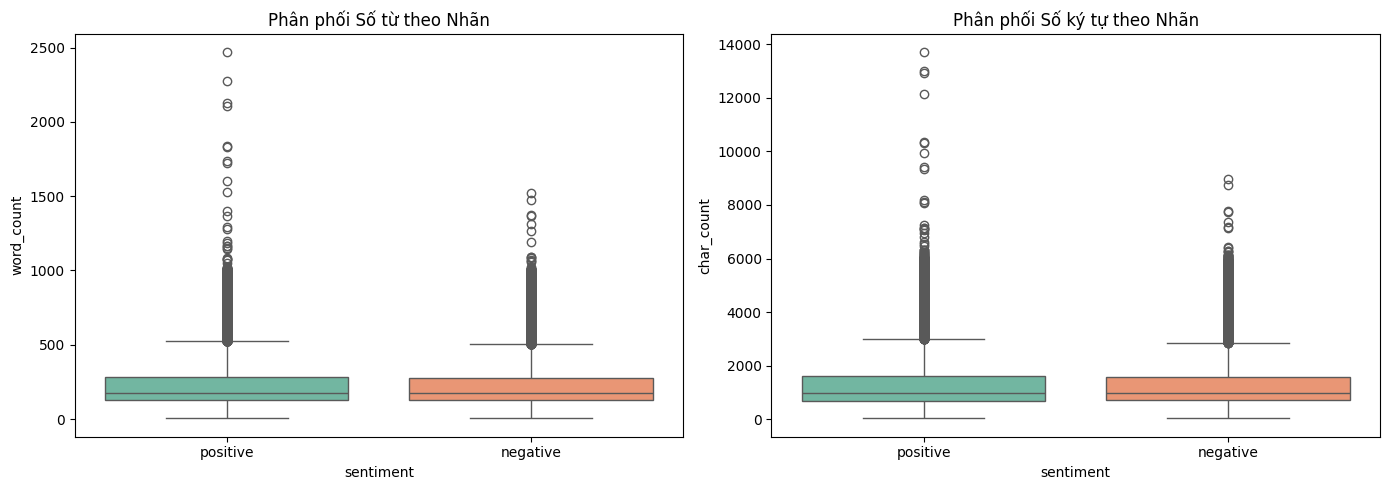

In [16]:
# 1. Tính toán số từ và số ký tự cho từng review

# Đếm số ký tự: Dùng thẳng hàm len() của chuỗi
df['char_count'] = df['review'].str.len()

# Đếm số từ: Cắt câu thành các từ, sau đó đếm số lượng từ đã cắt
df['word_count'] = df['review'].str.split().str.len()

# 2. Hiển thị bảng thống kê mô tả theo từng nhãn
print("--- Thống kê độ dài văn bản theo nhãn ---")
thong_ke = df.groupby('sentiment')[['word_count', 'char_count']].describe()
display(thong_ke)
# 3. Vẽ biểu đồ Boxplot để so sánh trực quan
# 3. Vẽ biểu đồ Boxplot để so sánh trực quan
plt.figure(figsize=(14, 5))

# Biểu đồ số từ
plt.subplot(1, 2, 1)
# Thêm hue='sentiment' và legend=False theo chuẩn mới của Seaborn
sns.boxplot(data=df, x='sentiment', y='word_count', hue='sentiment', palette='Set2', legend=False)
plt.title('Phân phối Số từ theo Nhãn')

# Biểu đồ số ký tự
plt.subplot(1, 2, 2)
# Thêm hue='sentiment' và legend=False theo chuẩn mới của Seaborn
sns.boxplot(data=df, x='sentiment', y='char_count', hue='sentiment', palette='Set2', legend=False)
plt.title('Phân phối Số ký tự theo Nhãn')

plt.tight_layout()
plt.show()

### Trả lời nhận xét Câu A2:

So sánh phân phối độ dài: Nhìn chung, độ dài văn bản giữa hai nhãn (Tích cực và Tiêu cực) là rất giống nhau. Tuy nhiên, nếu xét kỹ ở giá trị trung bình (Mean), nhãn positive (233 từ) nhỉnh hơn một chút xíu so với negative (229 từ). Bài đánh giá có độ dài "khủng" nhất trong tập dữ liệu cũng thuộc về nhãn Tích cực (2470 từ).

Độ dài văn bản có tương quan với nhãn phân loại không? Tại sao? Trong tập dữ liệu IMDB này, độ dài văn bản KHÔNG có sự tương quan đáng kể với nhãn.
Lý do: Tâm lý của con người khi viết bình luận phim ảnh thường khá giống nhau. Một người cực kỳ ghét bộ phim có thể viết một bài chê bai rất dài để chỉ ra từng lỗi kịch bản. Ngược lại, một người rất thích phim cũng có thể viết một bài phân tích dài không kém để khen ngợi diễn xuất và ý nghĩa. Do đó, độ dài (ngắn/dài) không giúp mô hình phân biệt được là họ đang khen hay chê. Mô hình buộc phải dựa vào ý nghĩa của các từ vựng cụ thể (như "tuyệt vời", "thảm họa", "đáng xem"...) chứ không thể dựa vào số lượng từ.

## Tiền sử lý văn bản


In [30]:

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 1. Tải các bộ từ điển cần thiết của NLTK (chỉ tải nếu máy chưa có)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# 2. Khởi tạo stopwords và lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Giữ lại các từ phủ định quan trọng
important_words = {'not', 'no', 'nor', 'but', 'against'}
stop_words = stop_words - important_words

# 3. Hàm tiền xử lý
def preprocess_text(text):
    # Chuyển chữ thường
    text = str(text).lower()
    
    # Xóa thẻ HTML (<br />)
    text = re.sub(r'<.*?>', ' ', text)
    
    # Xóa link URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Xóa ký tự đặc biệt, dấu câu, số
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tách từ và loại bỏ stopwords + Lemmatization
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(cleaned_words)

print("Đang tiến hành tiền xử lý bằng NLTK...")
print("Vui lòng đợi khoảng 1-2 phút. Không bấm nút Dừng (Interrupt)...")

# 4. Áp dụng vào DataFrame
df['cleaned_review'] = df['review'].apply(preprocess_text)

print("Tiền xử lý hoàn tất!")
display(df[['review', 'cleaned_review']].head())

Đang tiến hành tiền xử lý bằng NLTK...
Vui lòng đợi khoảng 1-2 phút. Không bấm nút Dừng (Interrupt)...
Tiền xử lý hoàn tất!


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


### Giải thích các bước xử lý dữ liệu:

**1. Chuyển toàn bộ văn bản về chữ thường (Lowercasing)**
* **Code áp dụng:** `text = str(text).lower()`
* **Lý do:** Đối với máy tính, ký tự viết hoa và viết thường có mã máy (ASCII/Unicode) khác nhau. Nếu không chuyển về chữ thường, máy tính sẽ coi "Movie", "MOVIE" và "movie" là 3 từ vựng hoàn toàn khác biệt.
* **Tác dụng:** Việc chuẩn hóa tất cả về chữ thường giúp đồng nhất dữ liệu, làm giảm đáng kể kích thước bộ từ vựng (vocabulary size) mà thuật toán phải học, từ đó giúp mô hình học nhanh hơn và khái quát hóa tốt hơn.

**2. Xóa các thẻ HTML (Removing HTML Tags)**
* **Code áp dụng:** `text = re.sub(r'<.*?>', ' ', text)`
* **Lý do:** Tập dữ liệu IMDB được thu thập (crawl) từ trang web, do đó trong các bài đánh giá có lẫn rất nhiều thẻ cấu trúc web, phổ biến nhất là thẻ ngắt dòng `<br />`. Các thẻ này chỉ có tác dụng hiển thị giao diện trên trình duyệt, hoàn toàn không mang bất kỳ giá trị ngôn ngữ hay cảm xúc nào.
* **Tác dụng:** Loại bỏ chúng để tránh làm nhiễu mô hình, không để mô hình học sai rằng `<br />` là một đặc trưng của nhận xét phim.

**3. Xóa đường dẫn liên kết (Removing URLs)**
* **Code áp dụng:** `text = re.sub(r'http\S+|www\S+|https\S+', '', text)`
* **Lý do:** Người dùng đôi khi dán link trailer phim hoặc link tham khảo vào bài đánh giá. Đối với máy tính, URL là một chuỗi ký tự ngẫu nhiên, dài và không có ý nghĩa về mặt ngữ nghĩa (ví dụ: `https://imdb.com/title/tt12345`).
* **Tác dụng:** Giống như thẻ HTML, việc xóa URL giúp làm sạch văn bản, loại bỏ các cụm ký tự vô nghĩa đối với bài toán phân loại sắc thái tình cảm.

**4. Xóa dấu câu, số và ký tự đặc biệt (Removing Punctuations & Numbers)**
* **Code áp dụng:** `text = re.sub(r'[^a-z\s]', ' ', text)` *(Chỉ giữ lại chữ cái từ a đến z và khoảng trắng)*
* **Lý do:** Các con số (1, 2, 3...) hay các dấu câu (!, ?, @, #, $, %, chấm, phẩy) trong đa số trường hợp không giúp ích nhiều cho việc xác định một bình luận là Tích cực hay Tiêu cực bằng các mô hình cơ bản (như Bag of Words hay TF-IDF).
* **Tác dụng:** Giúp tách các từ ra một cách rõ ràng nhất. Ví dụ: Từ "great!!!", "great," và "great" sau khi xóa dấu câu sẽ đều trở thành một từ duy nhất là "great".

**5. Tách từ (Tokenization) và Loại bỏ Từ dừng (Removing Stopwords)**
* **Code áp dụng:** `if word not in stop_words`
* **Lý do:** Từ dừng (Stopwords) là những từ xuất hiện với tần suất cực kỳ dày đặc trong câu nhưng chỉ đóng vai trò nối cấu trúc ngữ pháp (ví dụ: the, a, an, is, are, in, at...). Chúng không mang ý nghĩa quyết định xem câu đó là khen hay chê. Xóa chúng đi giúp mô hình tập trung 100% "sự chú ý" vào các từ khóa mang cảm xúc (như excellent, terrible, boring).
* **Giải thích ngoại lệ cực kỳ quan trọng:** Trong code, chúng ta đã cố tình giữ lại các từ mang nghĩa phủ định (như not, no, but). Lý do là vì chúng có khả năng đảo ngược hoàn toàn cực cảm xúc của câu. Nếu ta xóa từ "not", một câu chê bai như "This movie is not good" sẽ biến thành "movie good" (phim hay) – làm mô hình dự đoán sai hoàn toàn.

**6. Chuẩn hóa hình thái từ (Lemmatization)**
* **Code áp dụng:** `lemmatizer.lemmatize(word)`
* **Lý do:** Trong tiếng Anh, một từ có thể bị biến đổi thành nhiều dạng khác nhau phụ thuộc vào thì hoặc số nhiều (Ví dụ: Động từ: watch, watches, watched, watching / Danh từ: movie, movies).
* **Tác dụng:** Lemmatization sử dụng từ điển ngôn ngữ học để đưa tất cả các biến thể này về một dạng gốc duy nhất (gọi là Lemma). Quá trình này giúp máy tính hiểu rằng dù người dùng viết là watched hay watching thì ý nghĩa cốt lõi vẫn là hành động "xem". Điều này tiếp tục làm giảm số lượng từ vựng dư thừa, giúp không gian vector của mô hình nhỏ gọn và chính xác hơn.

## A3 Làm sạch văn bản

In [36]:

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Khởi tạo các công cụ
stop_words = set(stopwords.words('english'))
stop_words = stop_words - {'not', 'no', 'nor', 'but', 'against'} 
lemmatizer = WordNetLemmatizer()

# Hàm tiền xử lý (Câu A3)
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(cleaned_tokens)

# ==========================================
# PHẦN IN KẾT QUẢ RA MÀN HÌNH
# ==========================================

# 1. In thử nghiệm nghiệm trên 1 câu ví dụ để kiểm tra hàm:
sample_text = "I am watching this movie <br> again! It's NOT better than I thought. https://imdb.com"
print("Câu gốc   :", sample_text)
print("Sau xử lý :", preprocess_text(sample_text))
print("-" * 50)

# 2. Áp dụng vào toàn bộ DataFrame và in ra 5 dòng đầu tiên:
df['cleaned_review'] = df['review'].apply(preprocess_text)

print("\n--- KẾT QUẢ 5 DÒNG ĐẦU TIÊN TRONG DATAFRAME ---")
# Dùng thư viện IPython để in bảng cho đẹp trong file ipynb

display(df[['review', 'cleaned_review']].head())

Câu gốc   : I am watching this movie <br> again! It's NOT better than I thought. https://imdb.com
Sau xử lý : watching movie not better thought
--------------------------------------------------

--- KẾT QUẢ 5 DÒNG ĐẦU TIÊN TRONG DATAFRAME ---


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...
